In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import sklearn as skl
import duckdb as ddb
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import pandas as pd

#COMANDI PER NUOVO FILE GIT (-> HO CREATO IL DATASET IN REPOSITORY 'DATA SCIENCE' GIA COLLEGATA A GIT)
- COMANDI NECESSARI:

        - git status (MI INDICHERA' 'UNTRACKED FILES')
        - git add CA_Corrispondence_Analysis.ipynb
        - git commit -m 'Ca_rev.1'
        - git push

In [3]:
df = pd.read_csv(r"C:\Users\valerio.fumasoli\Desktop\DATASET DATASCIENCE\dataset_analisi_corrispondenze.csv")

In [4]:
display(df)

,ID,Nominativo,Eta,Genere,Citta,Tipologia_Prodotto_1,Brand_Prodotto_1,Caratteristica_Prodotto_1,Tipologia_Prodotto_2,Brand_Prodotto_2,Caratteristica_Prodotto_2
0,1,Stefano Ferrari,19,F,Napoli,Automobili,BMW,Sportivita,Smartphone,Samsung,Fotocamera
1,2,Giulia Mariani,45,M,Milano,Automobili,BMW,Lusso,Smartphone,Samsung,Fotocamera
2,3,Nicola Santoro,44,M,Padova,Automobili,Toyota,Sportivita,Smartphone,Apple,Sistema_Operativo
3,4,Nicola Lombardi,39,F,Torino,Automobili,BMW,Sportivita,Smartphone,Apple,Prezzo
4,5,Martina Giordano,56,F,Milano,Automobili,Toyota,Affidabilita,Smartphone,Xiaomi,Prezzo
...,...,...,...,...,...,...,...,...,...,...,...
1195,1196,Lorenzo Ferrari,25,F,Genova,Automobili,BMW,Lusso,Smartphone,Apple,Design
1196,1197,Giulia Barbieri,41,M,Bari,Automobili,BMW,Sportivita,Smartphone,Samsung,Prestazioni
1197,1198,Stefano Colombo,31,F,Bari,Automobili,Fiat,Economicita,Smartphone,Samsung,Design
1198,1199,Elisa Rossi,29,M,Roma,Automobili,Fiat,Innovazione,Smartphone,Samsung,Fotocamera


**ESPLORATIVA - EDA**

In [5]:
df.describe(include='all')

,ID,Nominativo,Eta,Genere,Citta,Tipologia_Prodotto_1,Brand_Prodotto_1,Caratteristica_Prodotto_1,Tipologia_Prodotto_2,Brand_Prodotto_2,Caratteristica_Prodotto_2
count,1200.000000,1200,1200.000000,1200,1200,1200,1200,1200,1200,1200,1200
unique,NaN,531,NaN,2,10,1,3,5,1,3,5
top,NaN,Alice Russo,NaN,F,Padova,Automobili,Toyota,Affidabilita,Smartphone,Samsung,Prestazioni
freq,NaN,7,NaN,625,137,1200,478,349,1200,562,274
mean,600.500000,NaN,44.180000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,346.554469,NaN,15.318828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,300.750000,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,600.500000,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,900.250000,NaN,58.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.dtypes

ID                           int64
Nominativo                     str
Eta                          int64
Genere                         str
Citta                          str
Tipologia_Prodotto_1           str
Brand_Prodotto_1               str
Caratteristica_Prodotto_1      str
Tipologia_Prodotto_2           str
Brand_Prodotto_2               str
Caratteristica_Prodotto_2      str
dtype: object

**esplorazione variabile eta**

In [7]:
citta = df.groupby('Citta')['Genere'].value_counts()
display(citta)

Citta    Genere
Bari     F         71
         M         63
Bologna  M         60
         F         58
Firenze  F         66
         M         45
Genova   M         61
         F         60
Milano   M         58
         F         53
Napoli   M         53
         F         53
Padova   F         72
         M         65
Roma     F         71
         M         56
Torino   F         62
         M         60
Verona   F         59
         M         54
Name: count, dtype: int64

In [8]:
# FUNZIONE PER DISTRIBUZIONE FREQUENZE
def distribuzione_frequenze(df, colonna, ordina_per="frequenza"):
    """
    Restituisce la distribuzione di frequenza di una variabile,
    valore per valore, con frequenza assoluta, % e % cumulata.
    
    ordina_per: "frequenza" (decrescente, utile per Pareto/segmentazione)
                oppure "valore" (ordine naturale dei valori)
    """
    
    freq = df[colonna].value_counts() # Conta quante volte compare ogni valore unico della colonna. # Di default value_counts() ordina già dal valore più frequente # al meno frequente (decrescente).
    
    if ordina_per == "valore":
     freq = freq.sort_index()# Se l'utente ha scelto ordina_per="valore", riordiniamo la serie  # in base all'indice (cioè ai valori stessi: 18, 19, 20... oppure  # in ordine alfabetico se è una variabile testuale), invece che
    # in base al conteggio.

    # Costruiamo un DataFrame con due colonne:
    # - "Frequenza": il conteggio assoluto (quante volte compare ogni valore)
    # - "Frequenza %": il conteggio trasformato in percentuale sul totale
    #   (freq / freq.sum() * 100), arrotondato a 2 decimali
    tab = pd.DataFrame({
        "Frequenza": freq,
        "Frequenza %": (freq / freq.sum() * 100).round(2),
    })
    
    tab["Frequenza Cumulata"] = tab["Frequenza"].cumsum() # Aggiungiamo la frequenza cumulata: per ogni riga, somma progressiva # delle frequenze assolute fino a quel punto (cumsum = cumulative sum). # Es: se le frequenze sono [10, 8, 5], la cumulata sarà [10, 18, 23].
    tab["Frequenza % Cumulata"] = tab["Frequenza %"].cumsum().round(2)# Stessa logica ma sulla percentuale: somma progressiva delle % fino # a quel punto. L'ultima riga arriverà sempre (circa) a 100%.
   
    return tab # Restituiamo la tabella finale pronta per essere ispezionata o stampata

In [9]:
display(distribuzione_frequenze(df, "Eta", ordina_per="valore"))

,Frequenza,Frequenza %,Frequenza Cumulata,Frequenza % Cumulata
Eta,,,,
18,21,1.75,21,1.75
19,19,1.58,40,3.33
20,25,2.08,65,5.41
21,20,1.67,85,7.08
22,13,1.08,98,8.16
23,26,2.17,124,10.33
24,28,2.33,152,12.66
25,26,2.17,178,14.83
26,21,1.75,199,16.58


In [10]:
#CREAZIONE ETA SEGMENTATA PER ESPLORATIVA (GROUPBY - PLOTS)
df['ETA_CL'] = df['Eta'].map(lambda x : 'under 30' if x < 30 else ('30 -45' if x < 45 else ('45-60' if x < 60 else 'over 60')))
display(df['ETA_CL'].value_counts())

ETA_CL
30 -45      342
45-60       324
under 30    272
over 60     262
Name: count, dtype: int64

In [11]:
df

,ID,Nominativo,Eta,Genere,Citta,Tipologia_Prodotto_1,Brand_Prodotto_1,Caratteristica_Prodotto_1,Tipologia_Prodotto_2,Brand_Prodotto_2,Caratteristica_Prodotto_2,ETA_CL
0,1,Stefano Ferrari,19,F,Napoli,Automobili,BMW,Sportivita,Smartphone,Samsung,Fotocamera,under 30
1,2,Giulia Mariani,45,M,Milano,Automobili,BMW,Lusso,Smartphone,Samsung,Fotocamera,45-60
2,3,Nicola Santoro,44,M,Padova,Automobili,Toyota,Sportivita,Smartphone,Apple,Sistema_Operativo,30 -45
3,4,Nicola Lombardi,39,F,Torino,Automobili,BMW,Sportivita,Smartphone,Apple,Prezzo,30 -45
4,5,Martina Giordano,56,F,Milano,Automobili,Toyota,Affidabilita,Smartphone,Xiaomi,Prezzo,45-60
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1196,Lorenzo Ferrari,25,F,Genova,Automobili,BMW,Lusso,Smartphone,Apple,Design,under 30
1196,1197,Giulia Barbieri,41,M,Bari,Automobili,BMW,Sportivita,Smartphone,Samsung,Prestazioni,30 -45
1197,1198,Stefano Colombo,31,F,Bari,Automobili,Fiat,Economicita,Smartphone,Samsung,Design,30 -45
1198,1199,Elisa Rossi,29,M,Roma,Automobili,Fiat,Innovazione,Smartphone,Samsung,Fotocamera,under 30


**ESPLORAZIONE GRAFICA**

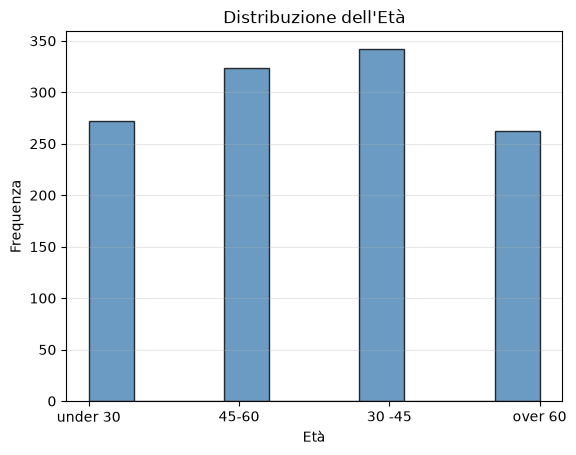

In [13]:
plt.hist(
    df["ETA_CL"],
    bins=10,            # numero di barre (oppure una lista di soglie, es. [18,25,35,45,55,65,100])
    edgecolor="black",  # bordo delle barre, per distinguerle meglio
    color="steelblue",  # colore di riempimento
    alpha=0.8           # trasparenza (0=trasparente, 1=opaco)
)
plt.title("Distribuzione dell'Età")
plt.xlabel("Età")
plt.ylabel("Frequenza")
plt.grid(axis="y", alpha=0.3)   # griglia leggera solo sull'asse y
plt.show()

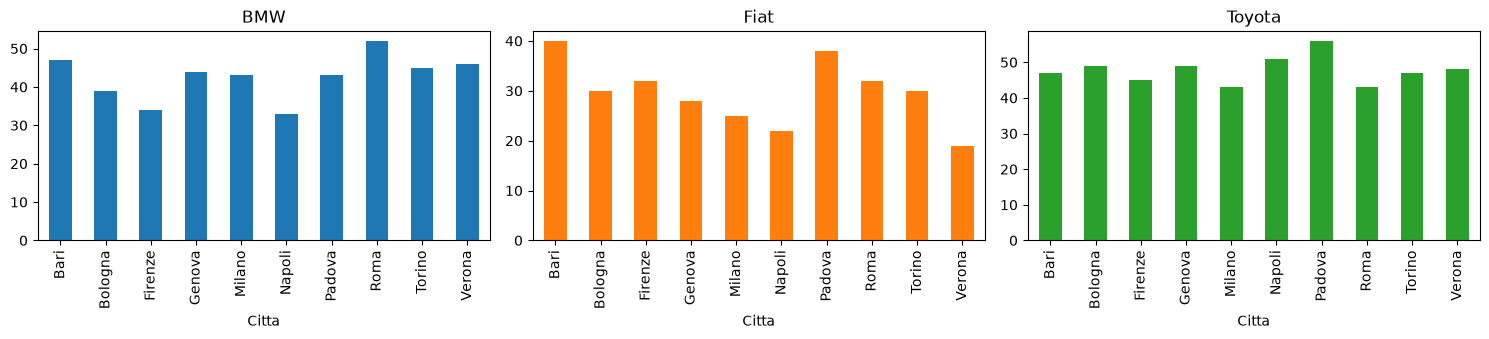

In [ ]:
df.groupby("Citta")["Brand_Prodotto_1"].value_counts().unstack().plot(
    kind="bar", subplots=True, layout=(-(-df["Citta"].nunique() // 3), 3),
    figsize=(15, 12), legend=False
)
plt.tight_layout()
plt.show()

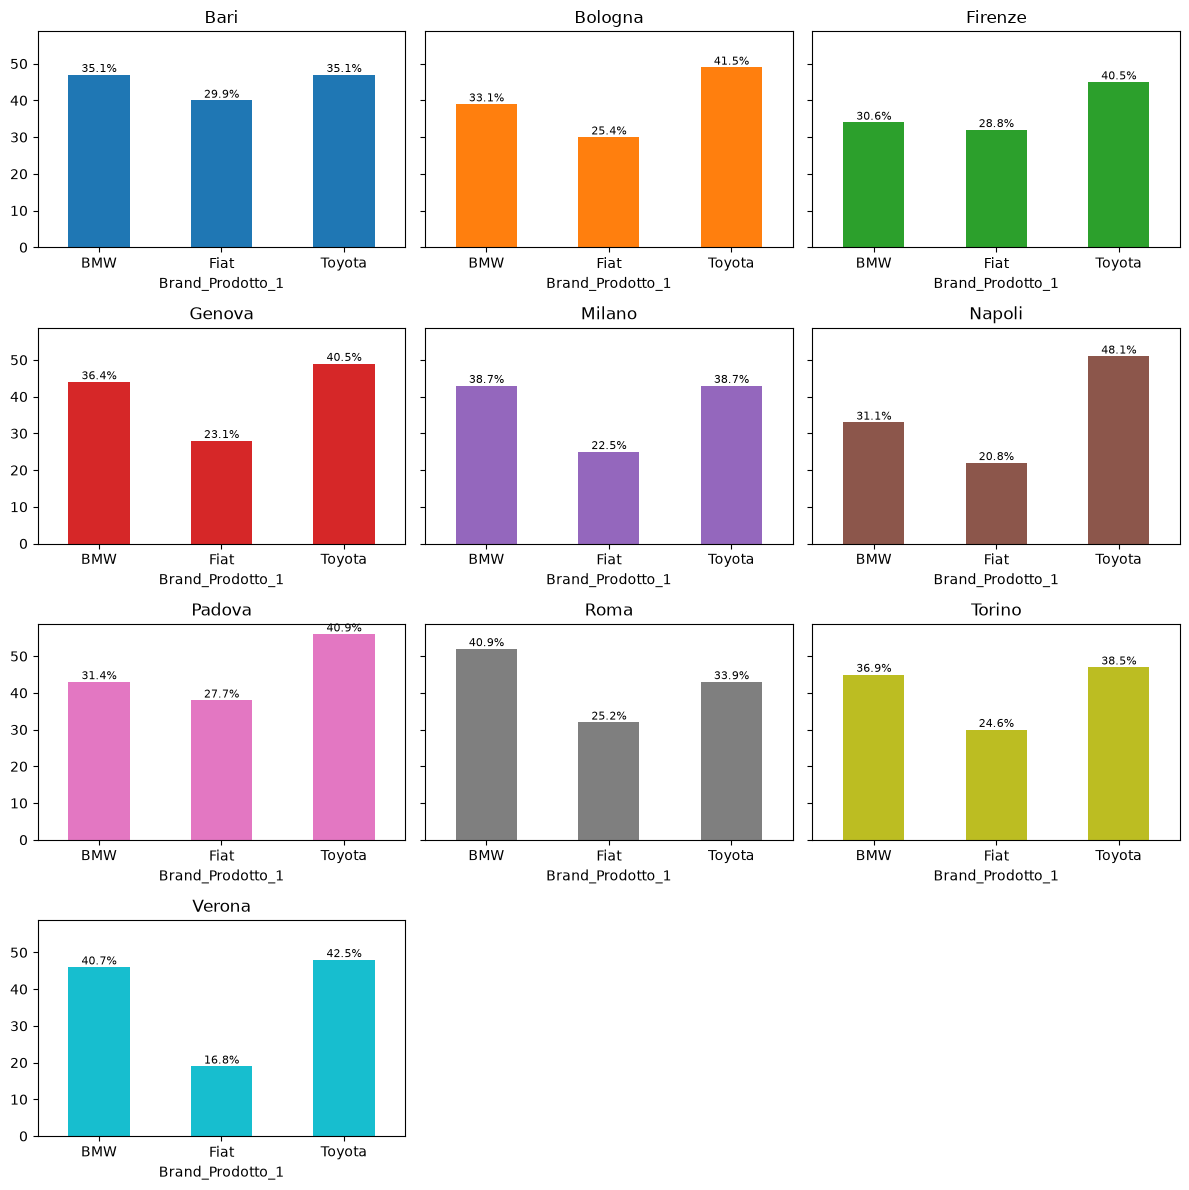

In [23]:
n_col = 3
n_row = -(-df["Citta"].nunique() // n_col)

axes = df.groupby("Brand_Prodotto_1")["Citta"].value_counts().unstack().plot(
    kind="bar", subplots=True, layout=(n_row, n_col),
    figsize=(12, 12), legend=False, sharey=True, sharex=False, rot=0
)

for ax in axes.flatten():
    if not ax.patches:
        continue
    totale = sum(p.get_height() for p in ax.patches)
    for p in ax.patches:
        ax.annotate(f"{p.get_height()/totale:.1%}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()